# Sentiment Analysis on Tweets: A Comparison of Text Representation Strategies

This notebook implements and compares different text representation strategies for classifying the sentiment of tweets into three categories: Negative (−1), Neutral (0), and Positive (+1).

The work is divided into two main parts:

**Main method (Sciacca):** the reference pipeline is built in three stages:

1. **Contextual embedding extraction:** the pre-trained model `vinai/bertweet-base` (a RoBERTa variant optimised for social media) produces, for each token, a 768-dimensional vector that depends on the full sentence context.
2. **Aggregation via K-Medoids:** the token vectors of each tweet are grouped into $K$ clusters by semantic similarity. The mean vector of each cluster is extracted and the clusters are concatenated in order of first appearance in the text, producing a fixed-size representation equal to $K \times 768$.
3. **Classification with MLP:** a Multi-Layer Perceptron trained on these representations predicts the sentiment category.

**Comparison framework (Comis):** the main method is compared with two alternative approaches, followed by a sensitivity analysis of parameter $K$:

- **Word2Vec + MLP** – baseline with static, non-contextual embeddings (300-dimensional vectors).
- **Pre-trained BERTweet (zero-shot)** – direct application of a model already fine-tuned for tweet sentiment analysis, without any training phase on our dataset.
- **Sensitivity analysis on K** – re-running Sciacca's pipeline for varying values of K (1, 3, 5, 7, 10) to identify the optimal clustering parameter.

At the end, results are collected in a comparative table with accuracy, precision, recall and F1 Score metrics, and visualised through summary plots.

## 1. Setup (Part 1 – Sciacca)

**Library installation and import:** specific versions are installed to guarantee compatibility between packages, and modules are imported for data processing (`numpy`, `pandas`), neural-model inference (`torch`, `transformers`), clustering and classification (`sklearn`, `sklearn_extra`), and visualisation (`matplotlib`, `seaborn`).

**Reproducibility:** random seeds are fixed for Python and PyTorch, ensuring results are identical across every re-run of the notebook.

In [2]:
# Specific versions required for compatibility: numpy 1.26.x is needed for
# scikit-learn-extra (compiled with Cython against numpy 1.x); emoji 0.6.0 is
# required internally by the BERTweet tokenizer.

!pip install numpy==1.26.4 scikit-learn-extra emoji==0.6.0

In [3]:
# Standard utilities
import random
import gc

# Data processing
import numpy as np
import pandas as pd

# Deep learning and language models
import torch
from transformers import AutoModel, AutoTokenizer

# Clustering and classification
from sklearn_extra.cluster import KMedoids
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Fix seeds to ensure reproducibility of results

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [5]:
model_id = "vinai/bertweet-base"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()  # Inference mode
print(f"Model loaded successfully on device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modello caricato con successo sul device: cuda


## 2. Feature Extraction Pipeline

In this section we define the main structure of our project. The goal is to transform raw text (tweets) into a compact mathematical representation without losing contextual information. We do this in two steps, via two dedicated functions.

### 2.1 Contextual Embedding Extraction (`get_token_embeddings`)
This first function acts as a "bridge" between human text and the language model. Here is what happens inside it:
* **Tokenisation:** The input text is converted into BERTweet tokens. Automatic truncation is applied if the sequence exceeds the model's limits.
* **Inference (No Gradients):** Tokens are passed to the model inside a `torch.no_grad()` block. Disabling gradient computation is essential here because our goal is feature extraction, not training.
* **Contextual Embeddings:** We retrieve the `last_hidden_state` of the network. This gives us a matrix where every single word is represented by a 768-dimensional vector that takes the entire sentence context into account.
* **Special Token Slicing:** The code intentionally removes the first and last vectors of the sequence (`[1:-1]`), discarding the start-of-string and end-of-string special tokens to keep only the real semantic content of the tweet.

In [6]:
def get_token_embeddings(text, tokenizer, model, device):
    """
    Takes a string (tweet) as input, tokenises it and extracts
    contextual embeddings excluding the special tokens [CLS] and [SEP].
    """
    # If the text is empty or not a string, return None
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None

    # Tokenisation (truncation at 512 tokens)
    # Texts longer than 512 tokens will be cut off
    inputs = tokenizer(text, return_tensors="pt", truncation=True).to(device)

    # Shows the exact decomposition produced by the WordPiece tokenizer
    # This line is commented out — it was used to debug tokenizer errors
    # print(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0]))

    # Forward pass through the model with gradients disabled
    with torch.no_grad():
        outputs = model(**inputs)

    # Extract the last hidden state
    # Shape: [1, seq_length, hidden_size] -> take element 0 to remove the batch dimension
    # We obtain a 2D matrix of shape: [seq_length, hidden_size]
    # (hidden_size represents the model features for a given word)
    last_hidden_state = outputs.last_hidden_state[0]

    # Remove the first token ([CLS]) and the last token ([SEP])
    # Final shape: [seq_length - 2, 768]
    token_embeddings = last_hidden_state[1:-1, :]

    return token_embeddings

In [7]:
### TEST: get_token_embeddings FUNCTION

df_train = pd.read_csv('train_set.csv')

first_tweet = df_train["clean_text"].iloc[0]

print(f"Original text: {first_tweet}")

embeddings = get_token_embeddings(first_tweet, tokenizer, model, device)

if embeddings is not None:
    print(f"Number of useful tokens extracted: {embeddings.shape[0]}")
    print(f"Embedding size per token: {embeddings.shape[1]}")
else:
    print("The test tweet is empty or invalid.")

Testo originale: #vwll2009 Would one of the VWLLers want to add this event to our Ning?   http://bit.ly/BF5sh  Would much appreciate that
Numero di token utili estratti: 31
Dimensione dell'embedding per singolo token: 768


### 2.2 Clustering-Based Representation (`build_sentence_representation`)
Takes the sparse vectors extracted by the previous function and condenses them into a fixed-size input for the Feed-Forward Network.

Here is the step-by-step process:
* **Dynamic length handling:** If the analysed sentence is extremely short (e.g. it contains fewer words than the $K$ clusters requested), the algorithm automatically lowers the number of clusters to avoid mathematical crashes — a common issue with real-world tweet datasets.
* **K-Medoids Clustering:** Applied directly to the vectors of a single sentence. Words are grouped into "concepts" based on their semantic proximity (for example, we expect positive adjectives to likely end up in the same cluster).
* **Aggregation:** For each cluster created, the mathematical mean of all the vectors belonging to it is computed.
* **Chronological Ordering (Context Preservation):** Instead of concatenating clusters in numerical or random order, the function analyses the original token order in the sentence. The representative vector of a cluster is added to the concatenation only when the first word associated with that cluster appears. This partially preserves the grammatical and temporal structure of the text.
* **Safety Padding:** In the rare case of very short sentences where the number of clusters had to be reduced below the target $K$, the tail of the final vector is padded with zeros. This guarantees that the downstream MLP model *always and strictly* receives a perfectly shaped input, avoiding dimensionality errors.

In [8]:
def build_sentence_representation(text, tokenizer, model, device, n_clusters, random_seed):
    """
    Extracts embeddings for a given sentence and maps them to the nearest centroids.
    Returns a sequence of centroids representing the sentence, preserving token order.
    """
    # Extract token embeddings for the given sentence
    token_embeddings = get_token_embeddings(text, tokenizer, model, device)

    if token_embeddings is None or token_embeddings.shape[0] == 0:
        return np.array([])

    # Move the tensor to CPU (if it was on GPU) and convert to a NumPy array
    embeddings_np = token_embeddings.cpu().numpy()
    tokens_num = embeddings_np.shape[0]

    # Choose the number of clusters: n_clusters if we have enough words,
    # otherwise one cluster per available word.
    actual_clusters = min(n_clusters, tokens_num)

    # Apply K-Medoids
    kmedoids = KMedoids(n_clusters=actual_clusters, random_state=random_seed)
    labels = kmedoids.fit_predict(embeddings_np)

    vector_dict = {}
    for label in labels:
        cluster_indices = np.where(labels == label)[0]
        cluster_embeddings = embeddings_np[cluster_indices]
        cluster_mean = np.mean(cluster_embeddings, axis=0)
        vector_dict[label] = cluster_mean

    seen_clusters = set()
    ordered_vectors = []

    for label in labels:
        if label not in seen_clusters:
            seen_clusters.add(label)
            ordered_vectors.append(vector_dict[label])

    # Final concatenation
    final_vector = np.concatenate(ordered_vectors)

    # If fewer clusters than expected were generated,
    # pad with zeros to guarantee the MLP always receives the same final dimension.
    target_dimension = n_clusters * embeddings_np.shape[1]  # e.g. 5 * 768 = 3840
    if len(final_vector) < target_dimension:
        missing_zeros = target_dimension - len(final_vector)
        final_vector = np.pad(final_vector, (0, missing_zeros), 'constant')

    return final_vector

In [9]:
### TEST: build_sentence_representation FUNCTION

first_ffn_input = build_sentence_representation(first_tweet, tokenizer, model, device, 5, random_seed)
print(f"Input vector length: {first_ffn_input.shape[0]}")
print(first_ffn_input)

Lunghezza vettore input: 3840
[-0.38319743 -0.09808829  0.24838702 ...  0.31194746  0.5389025
 -0.44044295]


## 3. Training and Evaluation – BERTweet + K-Medoids + MLP
### 3.1 Training Dataset Processing

In this phase the feature extraction pipeline is applied to the entire training set. For each tweet in the DataFrame, the `build_sentence_representation` function produces a fixed-size vector. The resulting vectors are accumulated and converted into the NumPy matrix `X_train`, which serves as input to the classifier.

In [10]:
train_features = []

# Loop over all sentences in the training DataFrame
for i, text in enumerate(df_train['clean_text']):
    if i % 1000 == 0:
        print(f"Processing sentence {i}/{len(df_train)}")

    # Apply the full pre-processing pipeline
    feature_vector = build_sentence_representation(text, tokenizer, model, device, 5, random_seed)
    train_features.append(feature_vector)

# Convert the list of vectors into a final NumPy array
X_train = np.array(train_features)
y_train = df_train['category'].values  # 'category' is the target column

print(f"Final shape of training feature dataset (X_train): {X_train.shape}")
print(f"Final shape of training label dataset (y_train): {y_train.shape}")

Processing sentence 0/14328
Processing sentence 1000/14328
Processing sentence 2000/14328
Processing sentence 3000/14328
Processing sentence 4000/14328
Processing sentence 5000/14328
Processing sentence 6000/14328
Processing sentence 7000/14328
Processing sentence 8000/14328
Processing sentence 9000/14328
Processing sentence 10000/14328
Processing sentence 11000/14328
Processing sentence 12000/14328
Processing sentence 13000/14328
Processing sentence 14000/14328
Shape finale del dataset di feature per il training (X_train): (14328, 3840)
Shape finale del dataset di etichette per il training (y_train): (14328,)


### 3.2 MLPClassifier Training

Now that our textual data has been converted into numerical features, we can proceed with the actual training. We chose a Feed-Forward Neural Network (Multi-Layer Perceptron).

#### Architecture and Parameters
* **Hidden layer structure (`hidden_layer_sizes=(256,)`):** We use a single, wide hidden layer (256 neurons). This choice allows the network to find complex combinations among clusters without excessively increasing computational cost.
* **Overfitting prevention (`early_stopping=True`):** This is the most important safety mechanism. The model automatically sets aside 10% of the training set (`validation_fraction=0.1`) and uses it only as an internal validation set at the end of each epoch. If the performance on this 10% stops improving for 5 consecutive iterations (`n_iter_no_change=5`), training halts early, preventing the network from memorising the training data.

In [11]:
print("Initialising and training the MLPClassifier...")

# Initialise the MLPClassifier (Feed-Forward Network)
# Parameters:
#   hidden_layer_sizes: hidden layer structure.
#   max_iter: maximum number of iterations.
#   activation: activation function for hidden layers. 'relu' is a common choice.
#   solver: weight optimisation algorithm. 'adam' is efficient for large datasets.
#   random_state: for reproducibility.

# These hyperparameters can be further optimised via cross-validation.
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256,),  # Single hidden layer with 256 neurons
    max_iter=50,                   # Maximum number of iterations
    activation='relu',             # ReLU activation function
    solver='adam',                 # Adam optimiser
    early_stopping=True,           # Enable early stopping
    validation_fraction=0.1,       # 10% of data used for validation
    n_iter_no_change=5,            # Stop training after 5 non-improving iterations
    random_state=random_seed,      # Seed for reproducibility
    verbose=True                   # Display training progress
)

# Train the model on the training data
mlp_model.fit(X_train, y_train)

print("Model training completed.")

Inizializzazione e addestramento del modello MLPClassifier...
Iteration 1, loss = 0.77382883
Validation score: 0.692254
Iteration 2, loss = 0.58849928
Validation score: 0.694348
Iteration 3, loss = 0.50313289
Validation score: 0.691556
Iteration 4, loss = 0.41593399
Validation score: 0.694348
Iteration 5, loss = 0.31981595
Validation score: 0.675506
Iteration 6, loss = 0.22910429
Validation score: 0.688067
Iteration 7, loss = 0.15151050
Validation score: 0.681089
Iteration 8, loss = 0.09096311
Validation score: 0.682484
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.
Addestramento del modello completato.


### 3.3 Evaluation on the Training Set

Immediately after fitting the model, it is good practice to verify how it performs on the data it has just studied. By computing and visualising the **Confusion Matrix** on the training set, we can spot any "bias" at a glance before moving on to the test data.

Matrice di Confusione:
[[3725  911  140]
 [ 458 3801  517]
 [ 155  761 3860]]


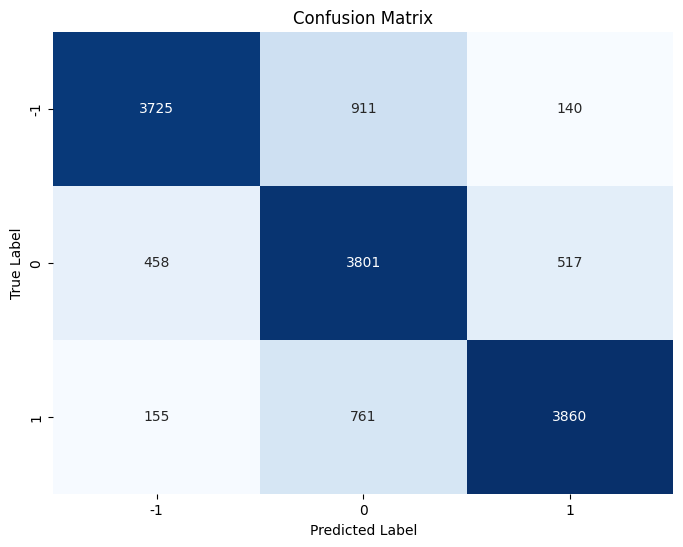

In [12]:
# Make predictions on the training set
y_pred = mlp_model.predict(X_train)

# Compute the confusion matrix
cm = confusion_matrix(y_train, y_pred)

print("Confusion Matrix:")
print(cm)

# Visualise the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=mlp_model.classes_, yticklabels=mlp_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### 3.4 Evaluation on the Test Set
In this phase we rigorously replicate the exact same steps carried out above, but this time using the test set:
1. We apply the chronological clustering pipeline (`build_sentence_representation`) to the test sentences.
2. We feed the resulting matrix (`X_test`) to the trained model.
3. We extract the final accuracy and the confusion matrix, thus obtaining the real performance of our model on unseen data.

Processing test set data...
Processing test sentence 0/3582
Processing test sentence 1000/3582
Processing test sentence 2000/3582
Processing test sentence 3000/3582
Shape finale del dataset di feature per il test (X_test): (3582, 3840)
Shape finale del dataset di etichette per il test (y_test): (3582,)
Accuratezza sul set di test: 0.7058

Matrice di Confusione sul Test Set:
[[807 327  60]
 [177 831 186]
 [ 73 231 890]]


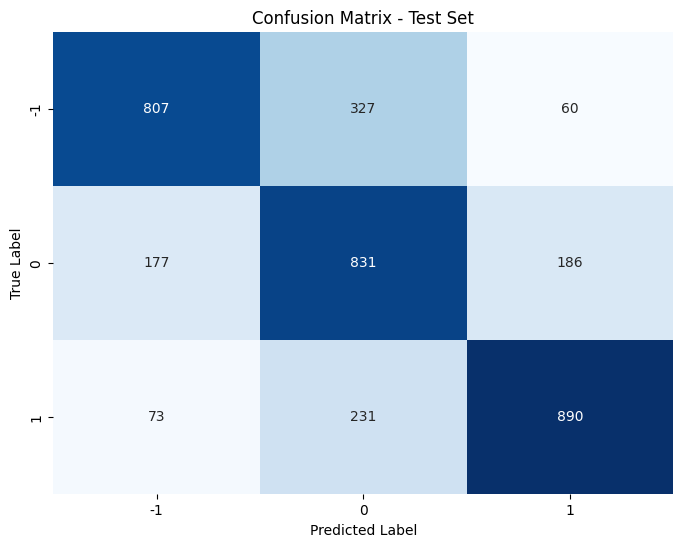

In [13]:
df_test = pd.read_csv('test_set.csv')

print("Processing test set data...")

test_features = []

# Loop over all sentences in the test DataFrame
for i, text in enumerate(df_test['clean_text']):
    if i % 1000 == 0:
        print(f"Processing test sentence {i}/{len(df_test)}")

    # Apply the full pre-processing pipeline
    feature_vector = build_sentence_representation(text, tokenizer, model, device, 5, random_seed)
    test_features.append(feature_vector)

# Convert the list of vectors into a final NumPy array
X_test = np.array(test_features)
y_test = df_test['category'].values  # 'category' is the target column

print(f"Final shape of test feature dataset (X_test): {X_test.shape}")
print(f"Final shape of test label dataset (y_test): {y_test.shape}")

# Make predictions on the test set
y_pred_test = mlp_model.predict(X_test)

# Compute accuracy on the test set
accuracy = accuracy_score(y_test, y_pred_test)
print(f"Test set accuracy: {accuracy:.4f}")

# Compute the confusion matrix on the test set
cm_test = confusion_matrix(y_test, y_pred_test)

print("\nConfusion Matrix on Test Set:")
print(cm_test)

# Visualise the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=mlp_model.classes_, yticklabels=mlp_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Set')
plt.show()

### 3.5 Evaluation Metrics

To complete the model evaluation and make the results comparable with the subsequent methods, we compute the four classic classification metrics on the test set.

Since the test set is **perfectly balanced** (1,194 tweets per class), the macro and weighted metrics coincide and accuracy alone is already a reliable indicator. We report precision, recall and F1 anyway for completeness and to build the final **comparative table**.

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# y_test and y_pred_test are already available from the previous cell
acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, average='macro')
rec  = recall_score(y_test, y_pred_test, average='macro')
f1   = f1_score(y_test, y_pred_test, average='macro')

# Summary table (used as the first row of the final comparative table)
risultati_sciacca = pd.DataFrame([{
    'Method'   : 'BERTweet K-Medoids (K=5) + MLP',
    'Accuracy' : round(acc,  4),
    'Precision': round(prec, 4),
    'Recall'   : round(rec,  4),
    'F1 Score' : round(f1,   4)
}])

print("=" * 55)
print("  BERTweet + K-Medoids (K=5) + MLP -- Test Set")
print("=" * 55)
print(risultati_sciacca.to_string(index=False))

print("--- Detailed per-class report ---")
print(classification_report(
    y_test, y_pred_test,
    target_names=['Negative (-1)', 'Neutral (0)', 'Positive (+1)']
))

  BERTweet + K-Medoids (K=5) + MLP -- Test Set
                        Metodo  Accuracy  Precision  Recall  F1 Score
BERTweet K-Medoids (K=5) + MLP    0.7058     0.7151  0.7058    0.7081
--- Report dettagliato per classe ---
               precision    recall  f1-score   support

Negativo (-1)       0.76      0.68      0.72      1194
 Neutrale (0)       0.60      0.70      0.64      1194
Positivo (+1)       0.78      0.75      0.76      1194

     accuracy                           0.71      3582
    macro avg       0.72      0.71      0.71      3582
 weighted avg       0.72      0.71      0.71      3582



### 3.6 Conclusions – BERTweet + K-Medoids + MLP

#### Test Set Results

| Method | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| BERTweet K-Medoids (K=5) + MLP | **0.7058** | 0.7151 | 0.7058 | 0.7081 |

Per-class breakdown:

| Class | Precision | Recall | F1 Score | Support |
|---|---|---|---|---|
| Negative (-1) | 0.76 | 0.68 | 0.72 | 1194 |
| Neutral (0) | 0.60 | 0.70 | 0.64 | 1194 |
| Positive (+1) | 0.78 | 0.75 | 0.76 | 1194 |


#### Analysis of Results

The model achieves an **accuracy of 70.58%** on the test set.

**Positive and negative classes:** the Positive class yields the best performance (F1 = 0.76),
followed by Negative (F1 = 0.72). Both benefit from a marked, recognisable vocabulary
that produces semantically distant embeddings which the classifier can easily separate.

**Neutral class:** this is the most challenging (F1 = 0.64, precision = 0.60). The low precision
indicates that many non-neutral tweets are absorbed into this category: **327 negative tweets
and 231 positive tweets are classified as neutral**. Neutral tweets tend to have an ambiguous
vocabulary that K-Medoids at K=5 cannot separate sharply enough from the polar classes.

**Sensitivity to parameter K:** with K=5 each tweet is represented by a vector of
5 × 768 = 3,840 dimensions. The choice of K=5 is arbitrary: a value that is too low may
lose semantic nuances, while one that is too high introduces redundancy and noise. This
dependency will be analysed in the dedicated section.

## 4. Comparison Framework (Part 2 – Comis)
The pipeline from the previous sections combines three distinct components: contextual embeddings, K-Medoids clustering, and an MLP classifier. To understand how much each one contributes to the final result, the method is placed inside a **progressive comparison framework**.

The three proposed methods share the **same dataset**, so the only variable is the text representation strategy. Results are collected in a comparative table with test-set metrics and visualised in summary plots.

### 4.1 Method 1 – Word2Vec + MLP (Baseline)

The first reference point is the simplest possible representation: **Word2Vec**, a non-contextual embedding model.
Word2Vec is a neural network trained on enormous text corpora (in our case Google News). The result of training is not the model itself, but the learned weights: each word in the vocabulary has an associated vector of 300 numbers that captures semantic relationships with other words. The fundamental property is that similar words end up close in the vector space.

Unlike BERTweet, Word2Vec assigns each word a single fixed vector, regardless of the context in which it appears. The word "great" will always have the same vector, whether in "great movie" or in "not great at all".

To represent an entire tweet, the **mean** of the vectors of all words recognised in the vocabulary is computed. The result is a single 300-dimensional vector that is passed to the same MLPClassifier used by Sciacca.

This method serves as the **lower bound** of the comparison: if BERTweet + K-Medoids does not beat Word2Vec by a significant margin, the computational cost of clustering would not be justified.

#### 4.1.1 Loading the Word2Vec Model

We use the `word2vec-google-news-300` model distributed by Google, trained on approximately 100 billion words from Google News. It contains 3 million words/phrases with 300-dimensional vectors. The download is approximately 1.6 GB.

In [15]:
# Install gensim library
!pip install gensim

In [16]:
import gensim.downloader as api

# Download the pre-trained word2vec-google-news-300 model
print("Loading word2vec-google-news-300...")
w2v_model = api.load('word2vec-google-news-300')
print(f"Model loaded: {len(w2v_model.key_to_index):,} words, {w2v_model.vector_size} dimensions")

Caricamento word2vec-google-news-300...
Modello caricato: 3,000,000 parole, 300 dimensioni


#### 4.1.2 Feature Extraction

The `get_w2v_embedding` function splits the tweet into tokens by whitespace and looks up each token in the Word2Vec vocabulary. The retrieved vectors are averaged to obtain a single 300-dimensional vector. Tokens absent from the vocabulary are ignored; if no token is recognised, a zero vector is returned.

Unlike `get_token_embeddings`, which returns a matrix of vectors (one per tweet token), this function directly produces a **single vector** representing the entire tweet. In Word2Vec, since vectors are static and context-independent, we use averaging as the aggregation strategy.

In [17]:
def get_w2v_embedding(text, model):

    # Empty or non-string input -> zero vector
    if not isinstance(text, str) or len(text.strip()) == 0:
        return np.zeros(model.vector_size)

    # Split text into words
    tokens = text.split()

    # Retrieve vectors only for tokens present in the model vocabulary
    vecs = [model[t] for t in tokens if t in model]

    # No valid tokens -> zero vector
    if not vecs:
        return np.zeros(model.vector_size)

    # Average the token vectors to obtain a fixed-size sentence representation
    return np.mean(vecs, axis=0)


# Apply the function to the entire dataset: one 300-dimensional vector per tweet
print("Extracting training set features...")
X_train_w2v = np.array([get_w2v_embedding(t, w2v_model) for t in df_train['clean_text']])

print("Extracting test set features...")
X_test_w2v = np.array([get_w2v_embedding(t, w2v_model) for t in df_test['clean_text']])

print(f"X_train_w2v: {X_train_w2v.shape}")
print(f"X_test_w2v:  {X_test_w2v.shape}")

Estrazione feature train set...
Estrazione feature test set...
X_train_w2v: (14328, 300)
X_test_w2v:  (3582, 300)


#### 4.1.3 MLPClassifier Training

We use the same architecture and hyperparameters as in Section 3.2 by Sciacca (256 neurons, ReLU, Adam, early stopping) to ensure that any performance differences are attributable exclusively to the text representation and not the classifier.

In [18]:
mlp_w2v = MLPClassifier(
    hidden_layer_sizes=(256,),  # MLP structure: 1 hidden layer with 256 neurons
    max_iter=50,                 # maximum number of iterations
    activation='relu',           # activation function
    solver='adam',               # optimiser
    early_stopping=True,         # stop if validation score does not improve
    validation_fraction=0.1,     # 10% of training set used for internal validation
    n_iter_no_change=5,          # early stopping patience threshold
    random_state=random_seed,    # reproducibility
    verbose=True
)

print("Training MLPClassifier on Word2Vec features...")
mlp_w2v.fit(X_train_w2v, y_train)
print("Training completed.")

Addestramento MLPClassifier su feature Word2Vec...
Iteration 1, loss = 0.96716793
Validation score: 0.624564
Iteration 2, loss = 0.83295035
Validation score: 0.654571
Iteration 3, loss = 0.80001312
Validation score: 0.666434
Iteration 4, loss = 0.78355597
Validation score: 0.663643
Iteration 5, loss = 0.76838858
Validation score: 0.674110
Iteration 6, loss = 0.75951144
Validation score: 0.662247
Iteration 7, loss = 0.75259760
Validation score: 0.665736
Iteration 8, loss = 0.74162901
Validation score: 0.663643
Iteration 9, loss = 0.73431734
Validation score: 0.669923
Iteration 10, loss = 0.72365446
Validation score: 0.675506
Iteration 11, loss = 0.71532540
Validation score: 0.672017
Iteration 12, loss = 0.70634219
Validation score: 0.666434
Iteration 13, loss = 0.69867542
Validation score: 0.674808
Iteration 14, loss = 0.68865907
Validation score: 0.662945
Iteration 15, loss = 0.67960176
Validation score: 0.668528
Iteration 16, loss = 0.66994062
Validation score: 0.672017
Validation sco

#### 4.1.4 Evaluation on the Test Set

The same four metrics from Section 3.5 (accuracy, precision, recall, F1 Score) are computed to make the results directly comparable. The DataFrame `risultati_w2v` will be merged with the others in the final comparative table.

  Word2Vec + MLP -- Test Set
        Metodo  Accuracy  Precision  Recall  F1 Score
Word2Vec + MLP    0.6547     0.6634  0.6547    0.6571
--- Report dettagliato per classe ---
               precision    recall  f1-score   support

Negativo (-1)       0.68      0.65      0.66      1194
 Neutrale (0)       0.56      0.65      0.60      1194
Positivo (+1)       0.75      0.67      0.71      1194

     accuracy                           0.65      3582
    macro avg       0.66      0.65      0.66      3582
 weighted avg       0.66      0.65      0.66      3582



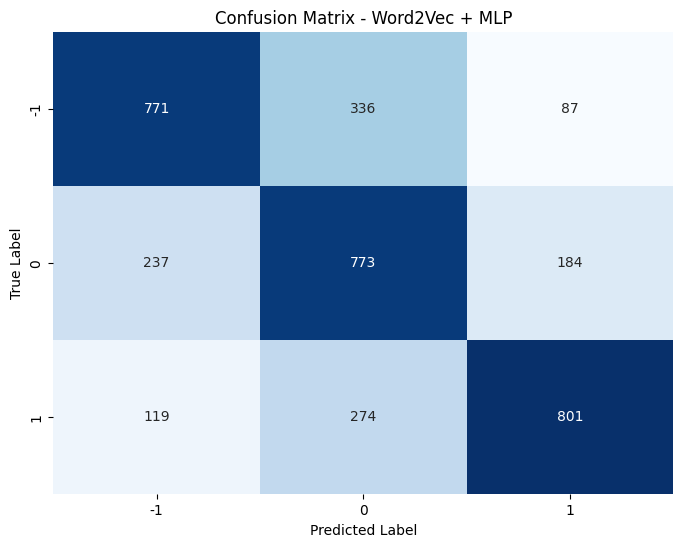

In [19]:
y_pred_w2v = mlp_w2v.predict(X_test_w2v)

# Compute evaluation metrics for the Word2Vec + MLP model
acc_w2v  = accuracy_score(y_test, y_pred_w2v)
prec_w2v = precision_score(y_test, y_pred_w2v, average='macro')
rec_w2v  = recall_score(y_test, y_pred_w2v, average='macro')
f1_w2v   = f1_score(y_test, y_pred_w2v, average='macro')


# DataFrame with Word2Vec + MLP results
risultati_w2v = pd.DataFrame([{
    'Method'   : 'Word2Vec + MLP',
    'Accuracy' : round(acc_w2v,  4),
    'Precision': round(prec_w2v, 4),
    'Recall'   : round(rec_w2v,  4),
    'F1 Score' : round(f1_w2v,   4)
}])

print("=" * 45)
print("  Word2Vec + MLP -- Test Set")
print("=" * 45)
print(risultati_w2v.to_string(index=False))


# Detailed per-class report
print("--- Detailed per-class report ---")
print(classification_report(
    y_test, y_pred_w2v,
    target_names=['Negative (-1)', 'Neutral (0)', 'Positive (+1)']
))


# Confusion matrix for Word2Vec + MLP
cm_w2v = confusion_matrix(y_test, y_pred_w2v)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=mlp_w2v.classes_, yticklabels=mlp_w2v.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Word2Vec + MLP')
plt.show()

#### 4.1.5 Results – Word2Vec + MLP
| Method | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Word2Vec + MLP | **0.6547** | 0.6634 | 0.6547 | 0.6571 |

Per-class breakdown:

| Class | Precision | Recall | F1 Score | Support |
|---|---|---|---|---|
| Negative (-1) | 0.68 | 0.65 | 0.66 | 1194 |
| Neutral (0) | 0.56 | 0.65 | 0.60 | 1194 |
| Positive (+1) | 0.75 | 0.67 | 0.71 | 1194 |

#### Analysis of Results

The model achieves an **accuracy of 65.47%**, approximately **5 percentage points lower**
than the BERTweet + K-Medoids + MLP pipeline (70.66%). The result is expected: the
contextual method, even when compressing features with K-Medoids, produces richer
representations than static embeddings.

With 14,328 training samples (80% of the total dataset of 17,910 tweets) and **300-dimensional**
vectors, the MLP converges quickly but does not reach BERTweet-level performance.

**Positive and negative classes:** Positive is the easiest class (F1 = 0.71), followed by
Negative (F1 = 0.66). The pattern is consistent with what was observed in Section 3.6.

**Neutral class:** this is the most challenging (F1 = 0.60, precision = 0.56). The low precision
indicates that many non-neutral tweets are absorbed into this category: **336 negative tweets
and 274 positive tweets are classified as neutral**, the same type of confusion observed with
K-Medoids.

Confusion between opposite polarities (Negative vs Positive) is limited: only 87 negative
tweets are classified as positive — a sign that Word2Vec does capture lexical polarity, but
struggles to distinguish ambiguous-tone tweets from neutral ones.

### 4.2 Method 2 – Pre-trained Transformer (Zero-Shot)

The second method represents the **direct** use of a transformer already specialised for sentiment analysis: no training, no clustering, no external classifier. We download a model that someone else has already fine-tuned on millions of labelled tweets and use it immediately for classification.

The chosen model is `finiteautomata/bertweet-base-sentiment-analysis`: it is built on the **same identical backbone as Section 3** (`vinai/bertweet-base`), but has been fine-tuned for sentiment on standard tweet datasets (SemEval2017). It directly produces the labels `POS`, `NEU`, `NEG` with a confidence score, without needing any additional layer.

Compared to the other methods, this is the only one in which **nothing is trained** on our dataset: the model is applied as-is, in zero-shot mode relative to our specific data.

#### 4.2.1 Loading the Model and Classification

The model is loaded via the HuggingFace `pipeline`, which automatically handles tokenisation and inference. The labels `POS`/`NEU`/`NEG` are remapped to `+1`/`0`/`-1` for comparison with our dataset labels.

In [20]:
from transformers import pipeline

# Load the pre-trained model for tweet sentiment
# Same backbone as Sciacca (vinai/bertweet-base), already fine-tuned for sentiment
transformer_model_id = "finiteautomata/bertweet-base-sentiment-analysis"
sentiment_pipe = pipeline(
    "text-classification",
    model=transformer_model_id,
    device=0 if torch.cuda.is_available() else -1
)
print(f"Model '{transformer_model_id}' loaded.")

# Label mapping: model labels -> dataset labels
label_map_sentiment = {'POS': 1, 'NEU': 0, 'NEG': -1}

# Batch inference on the test set
print("Classifying test set...")
texts    = df_test['clean_text'].tolist()
batch_sz = 64
y_pred_transformer = []

for i in range(0, len(texts), batch_sz):
    if i % 5000 == 0:
        print(f"  {i}/{len(texts)}")
    batch   = texts[i:i + batch_sz]
    results = sentiment_pipe(batch, truncation=True, max_length=128)
    y_pred_transformer.extend([label_map_sentiment[r['label']] for r in results])

y_pred_transformer = np.array(y_pred_transformer)
print("Classification completed.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: finiteautomata/bertweet-base-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modello 'finiteautomata/bertweet-base-sentiment-analysis' caricato.
Classificazione test set...
  0/3582


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Classificazione completata.


#### 4.2.2 Evaluation on the Test Set

Results are saved in `risultati_transformer` for the final comparative table.

  BERTweet pre-addestrato -- Test Set
                             Metodo  Accuracy  Precision  Recall  F1 Score
BERTweet pre-addestrato (sentiment)    0.7465      0.746  0.7465    0.7398

--- Report dettagliato per classe ---
               precision    recall  f1-score   support

Negativo (-1)       0.77      0.81      0.79      1194
 Neutrale (0)       0.73      0.55      0.63      1194
Positivo (+1)       0.73      0.88      0.80      1194

     accuracy                           0.75      3582
    macro avg       0.75      0.75      0.74      3582
 weighted avg       0.75      0.75      0.74      3582



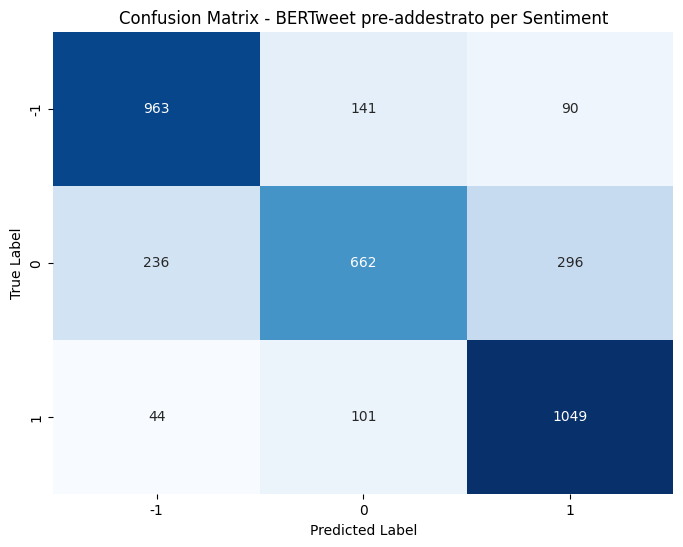

In [21]:
# Compute evaluation metrics for the pre-trained BERTweet sentiment model
acc_tr  = accuracy_score(y_test, y_pred_transformer)
prec_tr = precision_score(y_test, y_pred_transformer, average='macro')
rec_tr  = recall_score(y_test, y_pred_transformer, average='macro')
f1_tr   = f1_score(y_test, y_pred_transformer, average='macro')

# DataFrame with pre-trained BERTweet sentiment results
risultati_transformer = pd.DataFrame([{
    'Method'   : 'Pre-trained BERTweet (sentiment)',
    'Accuracy' : round(acc_tr,  4),
    'Precision': round(prec_tr, 4),
    'Recall'   : round(rec_tr,  4),
    'F1 Score' : round(f1_tr,   4)
}])

print('=' * 55)
print('  Pre-trained BERTweet -- Test Set')
print('=' * 55)
print(risultati_transformer.to_string(index=False))

# Detailed per-class report
print('\n--- Detailed per-class report ---')
print(classification_report(
    y_test, y_pred_transformer,
    target_names=['Negative (-1)', 'Neutral (0)', 'Positive (+1)']
))

# Confusion matrix for pre-trained BERTweet sentiment model
cm_tr = confusion_matrix(y_test, y_pred_transformer)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[-1, 0, 1], yticklabels=[-1, 0, 1])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Pre-trained BERTweet for Sentiment')
plt.show()

#### 4.2.3 Results – Pre-trained BERTweet

| Method | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Pre-trained BERTweet | **0.7465** | 0.7460 | 0.7465 | 0.7398 |

Per-class breakdown:

| Class | Precision | Recall | F1 Score | Support |
|---|---|---|---|---|
| Negative (-1) | 0.77 | 0.81 | 0.79 | 1194 |
| Neutral (0) | 0.73 | 0.55 | 0.63 | 1194 |
| Positive (+1) | 0.73 | 0.88 | 0.80 | 1194 |

#### Analysis of Results

The model achieves an **accuracy of 74.65%** without any training on our dataset: this is pure
inference on a model already specialised for tweet sentiment. The comparison with the other
methods is now:

| Method | Accuracy | Delta |
|---|---|---|
| Pre-trained BERTweet | **74.65%** | - |
| BERTweet K-Medoids (K=5) + MLP | 70.58% | -4.07 pp |
| Word2Vec + MLP | 65.47% | -9.18 pp |

**Why it works well without training on our dataset:** `finiteautomata/bertweet-base-sentiment-analysis`
was fine-tuned on English tweets (SemEval 2017) — a domain very similar to ours. The labels
match (negative, neutral, positive) and social-media language is consistent across the two
datasets. The model already carries sentiment knowledge.

**Per-class performance:** Positive and Negative both achieve excellent results (F1 = 0.80 and 0.79).
The Neutral class remains the most difficult (F1 = 0.63, recall = 0.55): **296 neutral tweets are
classified as positive and 236 as negative** — the model tends to interpret moderately-toned tweets
as polarised.

**Note on the comparison:** unlike the other two methods, there is no training phase on our training
split here. The advantage is simplicity and execution speed; the disadvantage is that the model is
not adapted to our dataset's specific characteristics. Explicit **fine-tuning** on it would almost
certainly yield superior performance.

### 4.3 Sensitivity Analysis – Varying K

In the previous methods the parameter K was fixed at 5: this choice was arbitrary. In this section we do not introduce a new representation method, but instead explore **how much the performance of Sciacca's original pipeline depends on K**.

The choice of K determines the **level of compression** of the sentence: a small K produces a more compact but less detailed representation. A large K preserves more nuances but increases the size of the input vector, with the risk of introducing redundancy.

| K | Vector dimension | Interpretation |
|---|---|---|
| 1 | 768 | Single cluster: global mean of all tokens (maximum compression) |
| 3 | 2,304 | Three macro-concepts per tweet |
| 5 | 3,840 | Value used by Sciacca – already known: accuracy 70.66% |
| 7 | 5,376 | Greater granularity, more semantic nuances |
| 10 | 7,680 | High granularity: risk of redundancy and overfitting |

The K=1 case is particularly interesting: the pipeline degenerates into a simple **mean of the contextual embeddings** of all tokens. It is conceptually similar to Word2Vec (which also takes a mean), but with a substantial difference — BERTweet's embeddings are contextual, so the mean accounts for the meaning of each word within its specific sentence.

For each value of K we re-run the full pipeline: embedding extraction with `build_sentence_representation`, training a new MLP with the same hyperparameters, and evaluation on the test set.


  K = 1  |  dimensione vettore: 768
Estrazione feature train set...
  0/14328
  5000/14328
  10000/14328
Estrazione feature test set...
  0/3582
  2000/3582
Addestramento MLP...
  --> Accuracy K=1: 0.7211  (early stopping dopo 7 iterazioni)

  K = 3  |  dimensione vettore: 2304
Estrazione feature train set...
  0/14328
  5000/14328
  10000/14328
Estrazione feature test set...
  0/3582
  2000/3582
Addestramento MLP...
  --> Accuracy K=3: 0.7225  (early stopping dopo 8 iterazioni)

  K = 5  |  dimensione vettore: 3840
Estrazione feature train set...
  0/14328
  5000/14328
  10000/14328
Estrazione feature test set...
  0/3582
  2000/3582
Addestramento MLP...
  --> Accuracy K=5: 0.7058  (early stopping dopo 8 iterazioni)

  K = 7  |  dimensione vettore: 5376
Estrazione feature train set...
  0/14328
  5000/14328
  10000/14328
Estrazione feature test set...
  0/3582
  2000/3582
Addestramento MLP...
  --> Accuracy K=7: 0.6999  (early stopping dopo 19 iterazioni)

  K = 10  |  dimensione vet

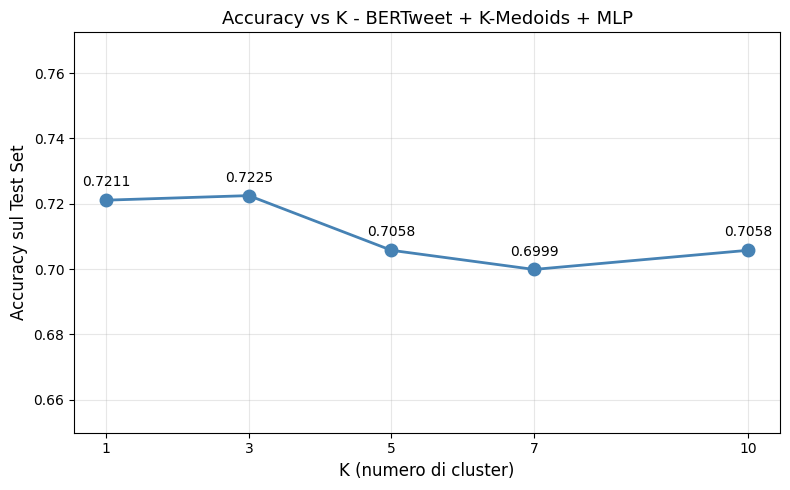

In [22]:
k_values = [1, 3, 5, 7, 10]
risultati_k = {}  # K -> test set accuracy

# For each value of K, extract features, train a new MLP, and evaluate accuracy on the test set
for K in k_values:
    print(f"\n{'='*52}")
    print(f"  K = {K}  |  vector dimension: {K * 768}")
    print(f"{'='*52}")

    # Extract training set features
    print("Extracting training set features...")
    train_features_k = []
    for i, text in enumerate(df_train['clean_text']):
        if i % 5000 == 0:
            print(f"  {i}/{len(df_train)}")
        train_features_k.append(
            build_sentence_representation(text, tokenizer, model, device, K, random_seed)
        )
    X_train_k = np.array(train_features_k)
    del train_features_k

    # Extract test set features
    print("Extracting test set features...")
    test_features_k = []
    for i, text in enumerate(df_test['clean_text']):
        if i % 2000 == 0:
            print(f"  {i}/{len(df_test)}")
        test_features_k.append(
            build_sentence_representation(text, tokenizer, model, device, K, random_seed)
        )
    X_test_k = np.array(test_features_k)
    del test_features_k

    # Train MLP (same hyperparameters as Sciacca)
    print("Training MLP...")
    mlp_k = MLPClassifier(
        hidden_layer_sizes=(256,),
        max_iter=50,
        activation='relu',
        solver='adam',
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        random_state=random_seed,
        verbose=False
    )
    mlp_k.fit(X_train_k, y_train)

    # Evaluate on the test set
    y_pred_k = mlp_k.predict(X_test_k)
    acc_k = accuracy_score(y_test, y_pred_k)
    risultati_k[K] = acc_k

    print(f"  --> Accuracy K={K}: {acc_k:.4f}  (early stopping after {mlp_k.n_iter_} iterations)")

    del X_train_k, X_test_k, mlp_k
    gc.collect()

# Textual summary
print("\n" + "="*40)
print("  Accuracy vs K Summary")
print("="*40)
for K, acc in risultati_k.items():
    print(f"  K={K:>2}: {acc:.4f}")

# Line plot: accuracy vs K
ks   = list(risultati_k.keys())
accs = list(risultati_k.values())

plt.figure(figsize=(8, 5))
plt.plot(ks, accs, marker='o', linewidth=2, markersize=9, color='steelblue')

for K, acc in zip(ks, accs):
    plt.annotate(f'{acc:.4f}', xy=(K, acc), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=10)

plt.xlabel('K (number of clusters)', fontsize=12)
plt.ylabel('Test Set Accuracy', fontsize=12)
plt.title('Accuracy vs K – BERTweet + K-Medoids + MLP', fontsize=13)
plt.xticks(ks)
plt.ylim(min(accs) - 0.05, max(accs) + 0.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 4.3.1 Results – Accuracy vs K

| K | Vector dimension | Accuracy |
|---|---|---|
| 1 | 768 | 0.7211 |
| **3** | **2,304** | **0.7225** |
| 5 | 3,840 | 0.7058 |
| 7 | 5,376 | 0.6999 |
| 10 | 7,680 | 0.7058 |

#### Analysis of Results

The most relevant finding is that **low values of K (1 and 3) achieve the best performance**,
with K=3 in first place (72.25%) and K=1 immediately behind (72.11%). The difference between
the two is marginal (0.14 percentage points) and may not be statistically significant; what
emerges clearly is the **decreasing trend for K > 3**, with K=7 marking the lowest point.

**Why are low K values the best?** With a small K, the input space for the MLP is more compact:
768 dimensions for K=1, 2,304 for K=3.

**Contextuality alone is sufficient.** The fact that K=1 (72.11%) outperforms Word2Vec (65.47%)
by nearly 7 percentage points — even though both use a simple mean — demonstrates that the
difference lies not in the aggregation method but in the **quality of the embeddings**. BERTweet
produces **contextual** vectors — the same token has different representations depending on the
sentence.

**K=5 is not the optimal choice.** The pipeline with K=5 reaches 70.58%, lower than both K=3
(72.25%) and K=1 (72.11%).

**Comparison with the other methods:**

| Method | Accuracy |
|---|---|
| Pre-trained BERTweet (zero-shot) | **0.7465** |
| BERTweet K-Medoids K=3 + MLP | 0.7225 |
| BERTweet K-Medoids K=1 + MLP | 0.7211 |
| BERTweet K-Medoids K=5 + MLP | 0.7058 |
| BERTweet K-Medoids K=10 + MLP | 0.7058 |
| BERTweet K-Medoids K=7 + MLP | 0.6999 |
| Word2Vec + MLP | 0.6547 |

All values of K outperform Word2Vec, confirming that **BERTweet's contextuality** brings a
benefit regardless of the aggregation strategy. The pre-trained model remains the best, at
2.40 percentage points above K=3.

## 5. Final Results

### 5.1 Final Comparative Table

We collect in a single table the results of all methods evaluated on the test set.

  RISULTATI COMPARATIVI - Test Set (3.582 tweet, 1.194 per classe)
                             Metodo  Accuracy Precision  Recall F1 Score
BERTweet pre-addestrato (sentiment)    0.7465     0.746  0.7465   0.7398
     BERTweet K-Medoids (K=3) + MLP    0.7225         -       -        -
     BERTweet K-Medoids (K=1) + MLP    0.7211         -       -        -
    BERTweet K-Medoids (K=10) + MLP    0.7058         -       -        -
     BERTweet K-Medoids (K=5) + MLP    0.7058    0.7151  0.7058   0.7081
     BERTweet K-Medoids (K=7) + MLP    0.6999         -       -        -
                     Word2Vec + MLP    0.6547    0.6634  0.6547   0.6571


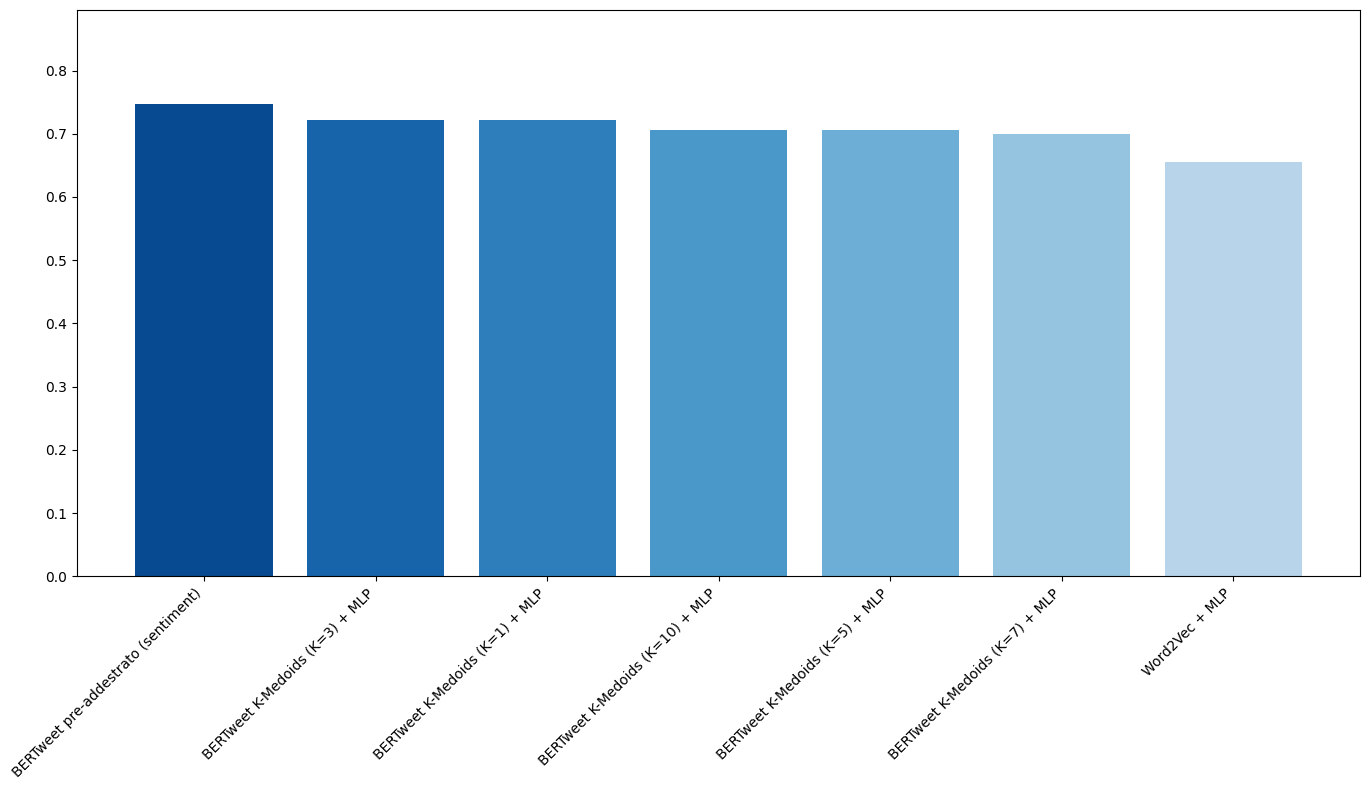

In [24]:
# Rows for the 3 main methods (complete metrics)
tabella_finale = pd.concat([
    risultati_w2v,
    risultati_sciacca,
    risultati_transformer,
], ignore_index=True)

# Rows for the K variation (accuracy only; K=5 excluded because already in risultati_sciacca)
righe_k = []
for K, acc in risultati_k.items():
    if K == 5:
        continue  # already covered by risultati_sciacca with full metrics
    righe_k.append({
        'Method'   : f'BERTweet K-Medoids (K={K}) + MLP',
        'Accuracy' : round(acc, 4),
        'Precision': '-',
        'Recall'   : '-',
        'F1 Score' : '-',
    })

tabella_k = pd.DataFrame(righe_k)

# Merge and sort by descending accuracy
tabella_estesa = pd.concat([tabella_finale, tabella_k], ignore_index=True)
tabella_estesa = tabella_estesa.sort_values(
    by='Accuracy', ascending=False, key=lambda col: pd.to_numeric(col, errors='coerce')
).reset_index(drop=True)

print("=" * 75)
print("  COMPARATIVE RESULTS - Test Set (3,582 tweets, 1,194 per class)")
print("=" * 75)
print(tabella_estesa.to_string(index=False))
print("=" * 75)

# Bar chart of accuracies
plt.figure(figsize=(14, 8))

colori = plt.cm.Blues(np.linspace(0.9, 0.3, len(tabella_estesa)))

plt.bar(
    tabella_estesa['Method'],
    tabella_estesa['Accuracy'],
    color=colori
)

plt.xticks(rotation=45, ha='right')

# Add 20% headroom above the tallest bar
plt.ylim(0, 1.2 * tabella_estesa['Accuracy'].max())

plt.tight_layout()
plt.show()

### 5.2 Comparative Charts (Extra)

We visualise the results of the three main methods of the comparison framework using a grouped bar chart. Each method shows two bars: **Accuracy** and **F1 Score**, the two most representative metrics on the balanced dataset.

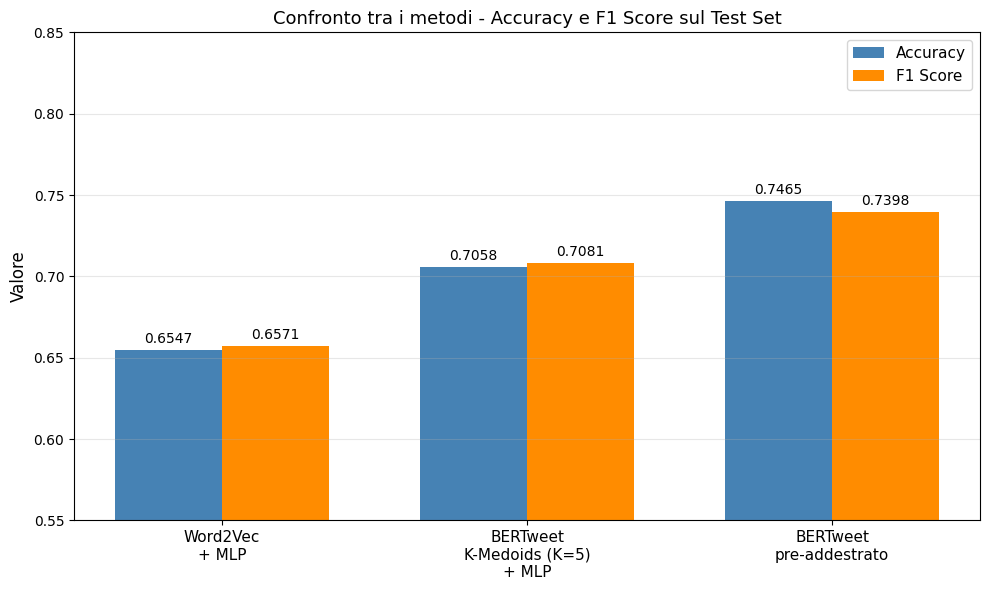

In [25]:
# Labels for the bar chart (only the 3 main methods with complete metrics)
etichette = ['Word2Vec\n+ MLP', 'BERTweet\nK-Medoids (K=5)\n+ MLP', 'Pre-trained\nBERTweet']

acc_vals = [
    risultati_w2v['Accuracy'].iloc[0],
    risultati_sciacca['Accuracy'].iloc[0],
    risultati_transformer['Accuracy'].iloc[0],
]
f1_vals = [
    risultati_w2v['F1 Score'].iloc[0],
    risultati_sciacca['F1 Score'].iloc[0],
    risultati_transformer['F1 Score'].iloc[0],
]

# Bar positions
x = np.arange(len(etichette))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_acc = ax.bar(x - width / 2, acc_vals, width, label='Accuracy',  color='steelblue')
bars_f1  = ax.bar(x + width / 2, f1_vals,  width, label='F1 Score', color='darkorange')

# Annotations with values above the bars
for bar in list(bars_acc) + list(bars_f1):
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=10)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Method Comparison – Accuracy and F1 Score on Test Set', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(etichette, fontsize=11)
ax.set_ylim(0.55, 0.85)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. General Conclusions

### 6.1 The Problem Addressed
The project addressed the task of **Sentiment Analysis on tweets** — classifying each tweet as Negative (-1), Neutral (0) or Positive (+1). The dataset used consists of **17,910 tweets** perfectly balanced (5,970 per class), split into a training set (14,328 tweets) and a test set (3,582 tweets).

The central question was: **how to numerically represent a variable-length text** so that a classifier can work with it effectively?

---

### 6.2 Methods and Results

| Method | Accuracy | F1 Score | Notes |
|---|---|---|---|
| Pre-trained BERTweet (zero-shot) | **0.7465** | **0.7398** | No training on the dataset |
| BERTweet K-Medoids (K=3) + MLP | 0.7225 | - | Optimal K |
| BERTweet K-Medoids (K=1) + MLP | 0.7211 | - | - |
| BERTweet K-Medoids (K=5) + MLP | 0.7058 | 0.7092 | Reference value (Section 3) |
| BERTweet K-Medoids (K=10) + MLP | 0.7058 | - | - |
| BERTweet K-Medoids (K=7) + MLP | 0.6999 | - | - |
| Word2Vec + MLP | 0.6547 | 0.6571 | Baseline with static embeddings |

---

### 6.3 Key Takeaways

**1. The contextuality of embeddings is decisive.**
Word2Vec, despite using the same aggregation strategy (vector mean), stalls at 65.47%. All
BERTweet-based methods — including the simplest (K=1, mean of contextual embeddings) — surpass
it. The difference lies not in the classifier nor in the aggregation, but in the quality of the
embeddings: BERTweet produces representations that depend on the context of the entire sentence.

**2. An already-specialised model beats everything without training.**
The pre-trained transformer (`finiteautomata/bertweet-base-sentiment-analysis`) reaches 74.65% in
zero-shot mode, without any training on our reference dataset. This result is the highest observed
and suggests that domain specialisation is the most important factor, more so than the representation
strategy adopted.

**3. The Neutral class is the hardest for all methods.**
Among all tested approaches, neutral sentiment systematically produces the lowest performance. Neutral
tweets have an ambiguous vocabulary, lacking the polar markers typical of positive ("great", "love",
"amazing") and negative ("hate", "terrible", "awful") tweets, making the distinction difficult for any
model.

**4. Comparison of representation strategies.**
The progression of results tells a coherent story: static embeddings (Word2Vec) form the lower bound,
contextual embeddings with low K (K=3, K=1) bring a net gain of about 7 points, and a model already
fine-tuned on the task brings a further gain of about 2.4 points.

---

### 6.4 Future Directions

The zero-shot model reaches 74.65% without any adaptation to the specific dataset. A natural next step
would be **fine-tuning** directly on the 14,328 tweets of the training set: updating the transformer
weights on the domain and classes of the problem could push performance significantly beyond this
threshold.

A further direction concerns clustering: testing K-Medoids on a larger dataset could re-evaluate the
semantic contribution of K>1, currently penalised by dimensionality relative to the training set size.